# Student Score Prediction using Linear Regression

### Import Libraries

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### Load Dataset

In [19]:
df = pd.read_csv("student_scores.csv")

print("First 5 Rows")
display(df.head())

First 5 Rows


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Basic Information

In [20]:
print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Description:")
display(df.describe())

Dataset Shape:
(1000, 8)

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Dataset Description:


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [21]:
print("\nCorrelation Matrix")

print(
    df[
        [
            "math score",
            "reading score",
            "writing score"
        ]
    ].corr()
)


Correlation Matrix
               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


### Inference:

Reading score and writing score show strong positive
correlation with mathematics score.

Students who perform well in reading and writing
generally perform well in mathematics.

### Score Distribution

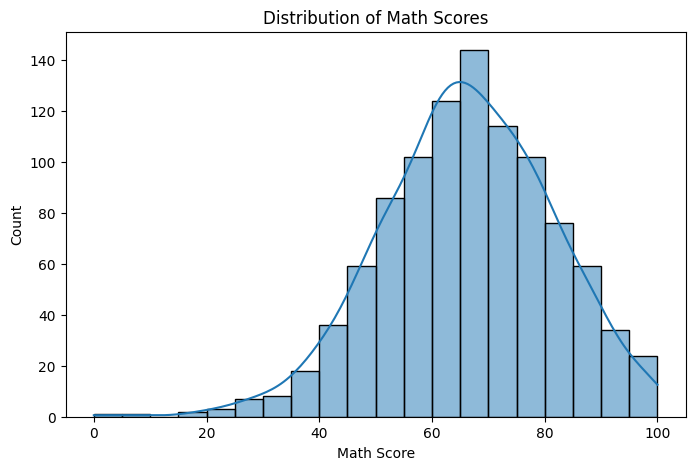

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["math score"],
    bins=20,
    kde=True
)

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Count")

plt.show()

### Reading vs Math Score

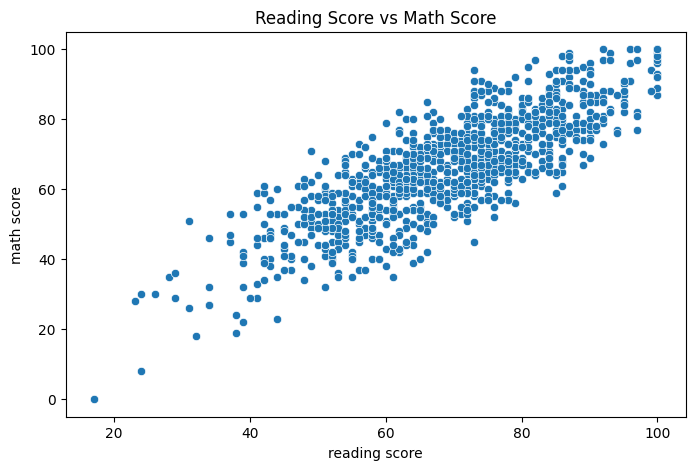

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="reading score",
    y="math score",
    data=df
)

plt.title("Reading Score vs Math Score")

plt.show()

### Writing vs Math Score

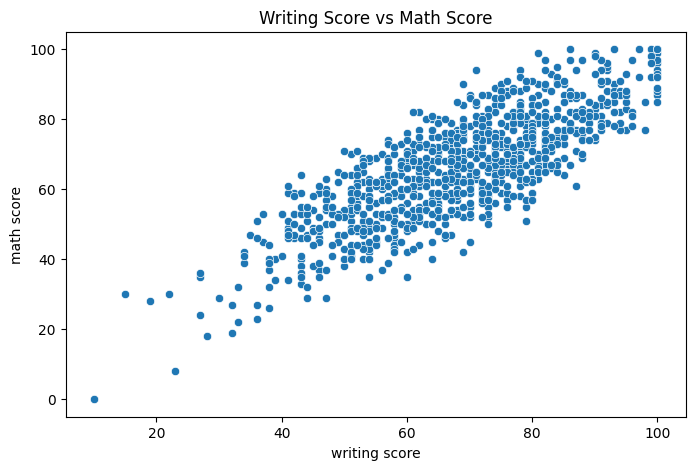

In [24]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="writing score",
    y="math score",
    data=df
)

plt.title("Writing Score vs Math Score")

plt.show()

### Correlation Heatmap

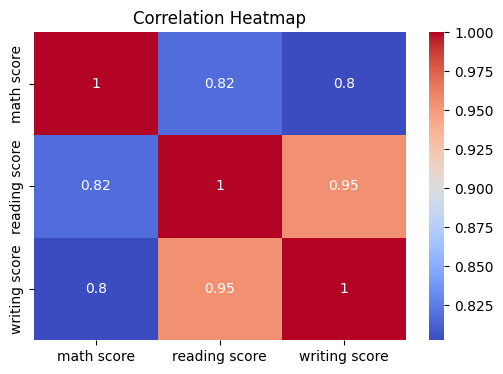

In [25]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df[[
        "math score",
        "reading score",
        "writing score"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

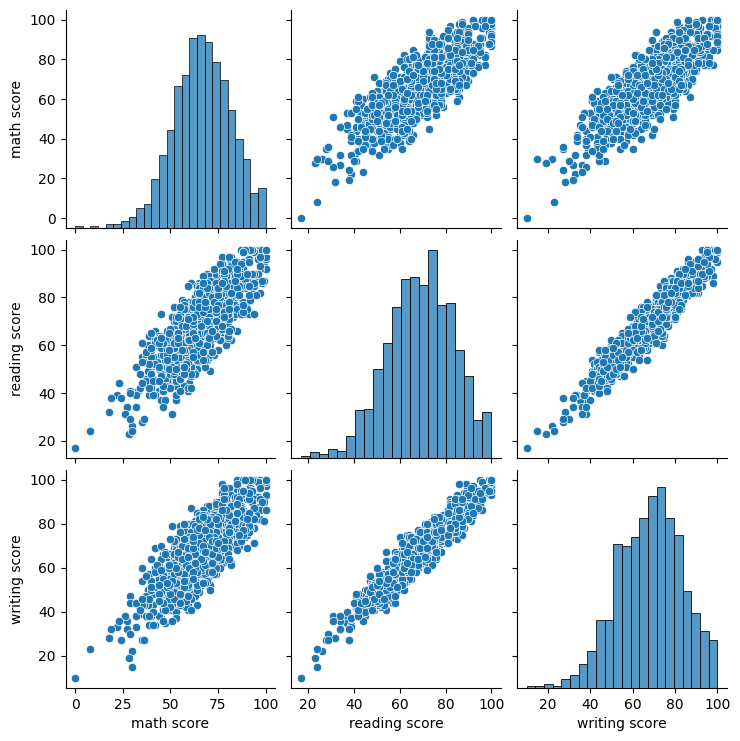

In [26]:
sns.pairplot(
    df[
        [
            "math score",
            "reading score",
            "writing score"
        ]
    ]
)

plt.show()

### Inference:

The pairplot shows a clear positive relationship
between reading, writing and mathematics scores.

Students with higher reading and writing scores
tend to achieve higher mathematics scores.

### Pairplot

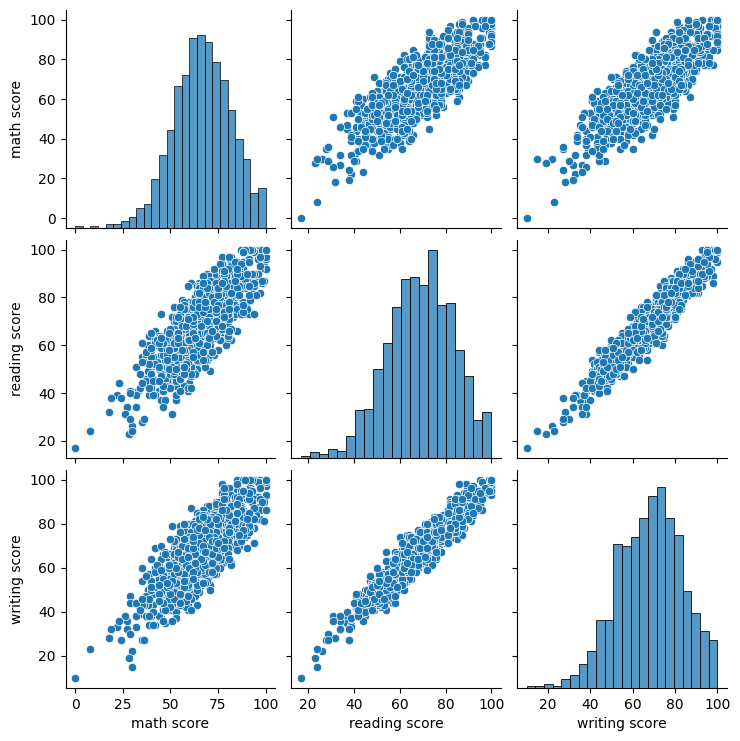

In [27]:
sns.pairplot(
    df[["math score","reading score","writing score"]]
)

plt.show()

### Features and Target

In [28]:
X = df[[
    "reading score",
    "writing score"
]]

y = df["math score"]

### Train Test Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 800
Testing Samples: 200


### Train Linear Regression Model

In [30]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

print("Intercept:")
print(model.intercept_)

print("\nCoefficients:")
print(model.coef_)

Intercept:
7.85940588782988

Coefficients:
[0.57555997 0.27176146]


### Inference:

The coefficients indicate how much the predicted
mathematics score changes when reading or writing
scores increase.

Both features positively contribute to the final
prediction.

### Prediction

In [31]:
predictions = model.predict(X_test)

print("\nFirst 10 Predictions")

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

display(results.head(10))


First 10 Predictions


,Actual,Predicted
0,91,80.185526
1,53,65.684950
2,80,69.442109
3,74,72.016110
4,84,76.828277
5,81,72.223797
6,69,65.269576
7,54,59.817775
8,87,69.442109
9,51,50.081864


### Evaluation

In [32]:
mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    predictions
)

print("\nModel Performance")

print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE:", round(rmse,2))
print("R2 Score:", round(r2,2))


Model Performance
MAE : 7.35
MSE : 77.24
RMSE: 8.79
R2 Score: 0.68


### Inference:

The low error values indicate that the model
predicts student scores reasonably well.

The R² score shows how much of the variation in
mathematics scores can be explained by reading
and writing scores.

### Actual vs Predicted

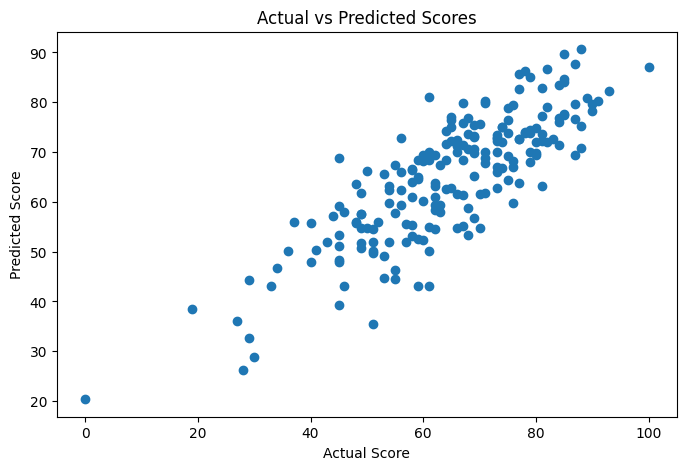

In [33]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")

plt.title("Actual vs Predicted Scores")

plt.show()

### Predict New Student

In [34]:
reading_score = 80
writing_score = 85

new_student = pd.DataFrame({
    "reading score":[reading_score],
    "writing score":[writing_score]
})

predicted_score = model.predict(
    new_student
)

print(
    "\nPredicted Math Score:",
    round(predicted_score[0],2)
)


Predicted Math Score: 77.0
